# BERT MBTI Personality Classifier Training

This notebook trains a BERT-based classifier to predict MBTI personality types from user reviews.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from transformers import AutoTokenizer
from src.config import get_config
from src.config.settings import PROCESSED_DATA_DIR, CHECKPOINT_DIR
from src.data.preprocessor import ReviewDataset
from src.data.sampler import DataSampler
from src.models.bert_mbti import (
    MBTIMultiLabelClassifier,
    MBTIClassifier,
    MBTITrainer,
    MBTIInference,
    create_data_loaders,
)
from src.utils.helpers import set_seed, get_device

# Setup
config = get_config()
set_seed(42)
device = get_device('cuda')  # or 'mps' for Apple Silicon, 'cpu'
print(f"Using device: {device}")
pd.set_option('display.max_colwidth', None)

Using device: cuda


## 1. Load and Prepare Data

In [2]:
mbti_csv_path = PROCESSED_DATA_DIR.parent / 'raw' / 'mbti_1.csv'

if mbti_csv_path.exists():
    mbti_df = pd.read_csv(mbti_csv_path)
    print(f"Loaded {len(mbti_df)} MBTI-labeled samples")
    print(f"Columns: {mbti_df.columns.tolist()}")
    
    # The Kaggle dataset has 'type' and 'posts' columns
    # 'posts' contains multiple posts separated by '|||'

    # Explode posts into individual rows
    #mbti_df['posts_list'] = mbti_df['posts'].str.split('|||')
    mbti_df['posts_list'] = mbti_df['posts'].str.split(r'\|\|\|')
    mbti_exploded = mbti_df.explode('posts_list').reset_index(drop=True)
    mbti_exploded = mbti_exploded.rename(columns={'type': 'mbti', 'posts_list': 'text'})
    mbti_exploded = mbti_exploded[['mbti', 'text']]
    
    # Clean text
    from src.data.preprocessor import TextPreprocessor
    preprocessor = TextPreprocessor()
    mbti_exploded = preprocessor.process_dataframe(mbti_exploded, text_column='text')
    
    print(f"After exploding: {len(mbti_exploded)} samples")
    print(f"MBTI distribution:\n{mbti_exploded['mbti'].value_counts()}")
    #print(mbti_exploded.head)
else:
    print(f"MBTI dataset not found at {mbti_csv_path}")
    print("Using synthetic labels for demonstration...")
    mbti_exploded = None

Loaded 8675 MBTI-labeled samples
Columns: ['type', 'posts']
After exploding: 411294 samples
MBTI distribution:
mbti
INFP    86987
INFJ    70096
INTP    61450
INTJ    51138
ENTP    33097
ENFP    32135
ISTP    15941
ISFP    12481
ENTJ    11033
ISTJ     9637
ENFJ     9137
ISFJ     7886
ESTP     4241
ESFP     2157
ESFJ     1997
ESTJ     1881
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import pandas as pd

# 1. SPLIT FIRST (This prevents Data Leakage!)
# We split the data BEFORE doing any upsampling.
if mbti_exploded is not None:
    # Split 80% train, 20% temp (which becomes 10% val, 10% test)
    train_df_original, temp_df = train_test_split(
        mbti_exploded, test_size=0.2, stratify=mbti_exploded['mbti'], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['mbti'], random_state=42
    )

    # 2. UPSAMPLE ONLY THE TRAINING SET
    # Find the size of the majority class in the training set
    majority_class_size = train_df_original['mbti'].value_counts().max()

    upsampled_classes = []

    # Loop through all 16 MBTI types
    for mbti_type in train_df_original['mbti'].unique():
        class_df = train_df_original[train_df_original['mbti'] == mbti_type]
        
        # If it's a minority class, upsample it to match the majority class
        if len(class_df) < majority_class_size:
            class_upsampled = resample(
                class_df, 
                replace=True,               # Sample with replacement (duplicate)
                n_samples=majority_class_size, # Match the exact size of the majority class
                random_state=42             # Keep it reproducible
            )
            upsampled_classes.append(class_upsampled)
        else:
            upsampled_classes.append(class_df)

    # 3. COMBINE AND SHUFFLE
    train_df = pd.concat(upsampled_classes).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Original Training Set Size: {len(train_df_original)}")
    print(f"Upsampled Training Set (train_df) Size: {len(train_df)}")
    print(f"Validation Set Size: {len(val_df)} | Test Set Size: {len(test_df)}")



Original Training Set Size: 329035
Upsampled Training Set (train_df) Size: 1113424
Validation Set Size: 41129 | Test Set Size: 41130


In [4]:
# 1. Save the original imbalanced data
train_df_imbalanced = train_df_original.copy()

# 2. Save the upsampled balanced data
train_df_balanced = pd.concat(upsampled_classes).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Imbalanced Training Set Size: {len(train_df_imbalanced)}")
print(f"Balanced Training Set Size: {len(train_df_balanced)}")
# The Validation set (val_df) remains the same for BOTH models!

Imbalanced Training Set Size: 329035
Balanced Training Set Size: 1113424


## 2. Visualize Class Distribution

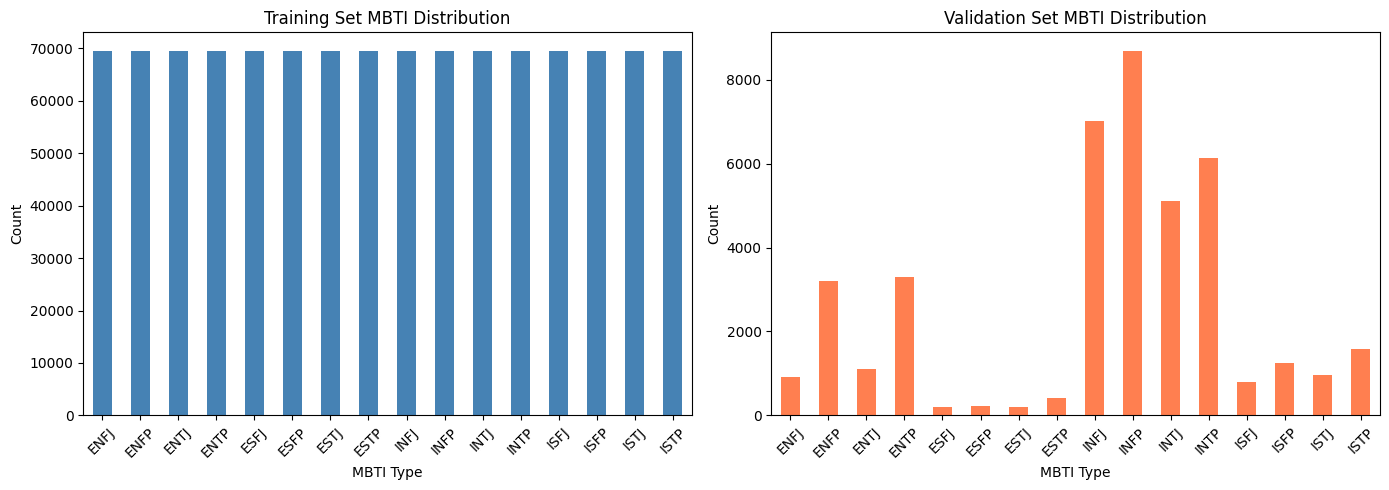

In [5]:
# Plot MBTI distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train distribution
train_counts = train_df['mbti'].value_counts().sort_index()
train_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Training Set MBTI Distribution')
axes[0].set_xlabel('MBTI Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Val distribution
val_counts = val_df['mbti'].value_counts().sort_index()
val_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Validation Set MBTI Distribution')
axes[1].set_xlabel('MBTI Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Create Datasets and DataLoaders

In [6]:
# Determine text column
text_col = 'clean_text' if 'clean_text' in train_df.columns else 'text'
print(f"Using text column: {text_col}")

# Create datasets
train_dataset = ReviewDataset.from_dataframe(
    train_df,
    text_column=text_col,
    label_column='mbti',
    config=config.bert,
)

val_dataset = ReviewDataset.from_dataframe(
    val_df,
    text_column=text_col,
    label_column='mbti',
    config=config.bert,
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")

Using text column: clean_text


Train dataset size: 1113424
Val dataset size: 41129


In [7]:
# 1. Create the Validation Dataset (used for both)
val_dataset = ReviewDataset(val_df, text_column='clean_text', label_column='mbti', config=config.bert)

# 2. Create Imbalanced Training Loader
train_dataset_imb = ReviewDataset(train_df_imbalanced, text_column='clean_text', label_column='mbti', config=config.bert)
train_loader_imb, val_loader = create_data_loaders(
    train_dataset_imb, val_dataset, batch_size=32, num_workers=0
)

# 3. Create Balanced Training Loader
train_dataset_bal = ReviewDataset(train_df_balanced, text_column='clean_text', label_column='mbti', config=config.bert)
train_loader_bal, _ = create_data_loaders(
    train_dataset_bal, val_dataset, batch_size=32, num_workers=0
)

In [8]:
# Inspect a sample
sample = train_dataset[0]
print("Sample keys:", sample.keys())
print("Input IDs shape:", sample['input_ids'].shape)
print("Attention mask shape:", sample['attention_mask'].shape)

# Reconstruct the MBTI type string from the individual labels
mbti_str = ""
mbti_str += "I" if sample['EI'].item() == 1 else "E"
mbti_str += "N" if sample['SN'].item() == 1 else "S"
mbti_str += "F" if sample['TF'].item() == 1 else "T"
mbti_str += "P" if sample['JP'].item() == 1 else "J"

print(f"Reconstructed Label: {mbti_str}")
print(f"Individual Tensors: EI={sample['EI'].item()}, SN={sample['SN'].item()}, TF={sample['TF'].item()}, JP={sample['JP'].item()}")

Sample keys: dict_keys(['input_ids', 'attention_mask', 'EI', 'SN', 'TF', 'JP'])
Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Reconstructed Label: ENFJ
Individual Tensors: EI=0, SN=1, TF=1, JP=0


In [9]:
# Create data loaders
BATCH_SIZE = 32   # Reduce if OOM

train_loader, val_loader = create_data_loaders(
    train_dataset,
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,  # Set to 0 for notebooks
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 34795
Val batches: 1286


## 4. Initialize Model and Trainer

In [10]:
train_df.head(10)

,mbti,text,clean_text
0,ENFJ,"Aww! Thanks for your kindness. :) its much needed. I just feel like its so hard to express myself and my emotions, which is why i'm drawn to this INFJ... He understands and KNOWS without me having to...","aww! thanks for your kindness. : its much needed. i just feel like its so hard to express myself and my emotions, which is why i'm drawn to this infj... he understands and knows without me having to..."
1,INFJ,"Hello thegirlcandance :) Never fought for love b4, but coming up with reasonings? Oh yeah! That's so me :D Yup I've tried but I'm moving on to keeping it just-friends for now. If it happens down...","hello thegirlcandance : never fought for love b4, but coming up with reasonings? oh yeah! that's so me :d yup i've tried but i'm moving on to keeping it just-friends for now. if it happens down..."
2,ENTP,I have no memory. Legit.,i have no memory. legit.
3,ISTP,"Just finished Zen and the Art of Motorcycle Maintenance not too long ago, first read. Like Randroth said, it's gonna take many readings to really soak it all in. Interesting perspectives. ...","just finished zen and the art of motorcycle maintenance not too long ago, first read. like randroth said, it's gonna take many readings to really soak it all in. interesting perspectives. ..."
4,ENTP,http://www.hawaiibusiness.com/images/2008/March2008/HBLife_0308/beer_threepic.jpg Show me YOU,show me you
5,ENTP,So lame I love it <3,so lame i love it 3
6,ISTP,I'm a Cancer. I was also born in July. :P,i'm a cancer. i was also born in july. :p
7,ENFP,"This is where it gets so interesting! Because i've had this discussion before in a way. It is reversed for me, compared to you. When I don't love someone yet, I can't be in a relationship and won't...","this is where it gets so interesting! because i've had this discussion before in a way. it is reversed for me, compared to you. when i don't love someone yet, i can't be in a relationship and won't..."
8,ENTP,Paranoid: Low Schizoid: Moderate Schizotypal: High Antisocial: Low Borderline: Low Histrionic: Low Narcissistic: Low Avoidant: Low Dependent: Low Obsessive-Compulsive: Low,paranoid: low schizoid: moderate schizotypal: high antisocial: low borderline: low histrionic: low narcissistic: low avoidant: low dependent: low obsessive-compulsive: low
9,INTJ,"Since you asked for opinions, I'm going to give you mine. You look come across as very angry and/or bitter in your OP and I can see that very same anger expressed through your picture. Everything...","since you asked for opinions, i'm going to give you mine. you look come across as very angry and or bitter in your op and i can see that very same anger expressed through your picture. everything..."


In [11]:
# Create model
model = MBTIMultiLabelClassifier(config=config.bert)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 109,488,392
Trainable parameters: 109,488,392


In [12]:
# Configure training
config.bert.num_epochs = 3  # Reduce for demo
config.bert.learning_rate = 2e-5
config.bert.early_stopping_patience = 2

In [13]:
import torch
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU


## 5. Train the Model

In [14]:
import torch
torch.cuda.empty_cache()
import gc
gc.collect()

98

In [15]:
print("--- TRAINING MODEL A: IMBALANCED DATA (BEFORE) ---")
model_imb = MBTIMultiLabelClassifier(config=config.bert)
trainer_imb = MBTITrainer(
    model=model_imb,
    train_loader=train_loader_imb,
    val_loader=val_loader, # Same val loader!
    config=config.bert
)

--- TRAINING MODEL A: IMBALANCED DATA (BEFORE) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
history_imb = trainer_imb.train()

Validating: 100%|██████████| 1286/1286 [01:06<00:00, 19.28it/s]


In [17]:
print("--- TRAINING MODEL B: BALANCED DATA (AFTER) ---")
model_bal = MBTIMultiLabelClassifier(config=config.bert)
trainer_bal = MBTITrainer(
    model=model_bal,
    train_loader=train_loader_bal,
    val_loader=val_loader, # Same val loader!
    config=config.bert
)

--- TRAINING MODEL B: BALANCED DATA (AFTER) ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
history_bal = trainer_bal.train()

Validating: 100%|██████████| 1286/1286 [01:03<00:00, 20.34it/s]


## 6. Evaluate the Model

In [19]:
# Table for BEFORE
df_before = pd.DataFrame(history_imb['val_history'])
df_before = df_before[['accuracy', 'f1_score', 'ei_acc', 'ns_acc', 'ft_acc', 'jp_acc']]
df_before.index = [f"Epoch {i+1}" for i in range(len(df_before))]
print("BEFORE UPSAMPLING:")
display(df_before.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.4f}"))

# Table for AFTER
df_after = pd.DataFrame(history_bal['val_history'])
df_after = df_after[['accuracy', 'f1_score', 'ei_acc', 'ns_acc', 'ft_acc', 'jp_acc']]
df_after.index = [f"Epoch {i+1}" for i in range(len(df_after))]
print("AFTER UPSAMPLING:")
display(df_after.style.background_gradient(cmap='RdYlGn', axis=0).format("{:.4f}"))

BEFORE UPSAMPLING:


,accuracy,f1_score,ei_acc,ns_acc,ft_acc,jp_acc
Epoch 1,0.7350,0.5997,0.7812,0.8693,0.6528,0.6366
Epoch 2,0.7383,0.6246,0.7830,0.8697,0.6606,0.6400
Epoch 3,0.7358,0.6383,0.7809,0.8686,0.6569,0.6368


AFTER UPSAMPLING:


,accuracy,f1_score,ei_acc,ns_acc,ft_acc,jp_acc
Epoch 1,0.6659,0.6105,0.7025,0.7277,0.6276,0.6056
Epoch 2,0.6808,0.6177,0.6937,0.7946,0.6272,0.6075
Epoch 3,0.6863,0.6230,0.7025,0.8135,0.6263,0.6030


In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from src.models.bert_mbti import MBTIClassifier

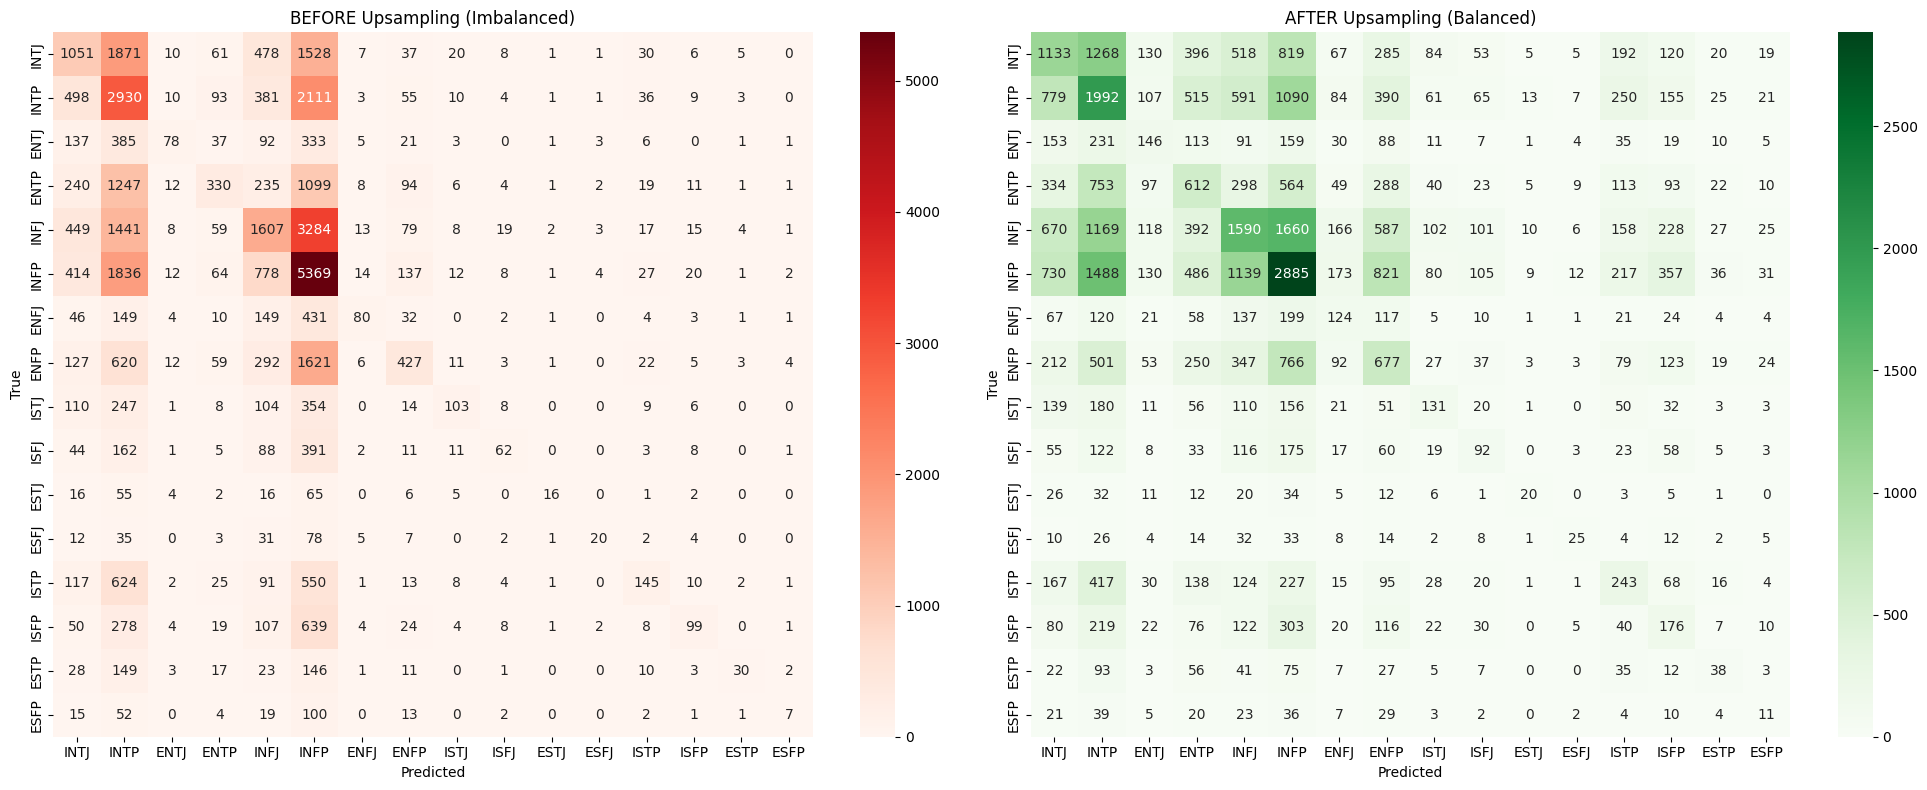

In [22]:
# 1. Gather predictions for BOTH models using the same validation set
all_labels = []
preds_imb = []
preds_bal = []

model_imb.eval()
model_bal.eval()

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        # Get predictions from both models
        preds_imb.extend(model_imb.predict_mbti_type(input_ids, attention_mask))
        preds_bal.extend(model_bal.predict_mbti_type(input_ids, attention_mask))
        
        # Reconstruct true labels
        batch_size = input_ids.size(0)
        for i in range(batch_size):
            mbti_str = ""
            mbti_str += "I" if batch['EI'][i].item() == 1 else "E"
            mbti_str += "N" if batch['SN'][i].item() == 1 else "S"
            mbti_str += "F" if batch['TF'][i].item() == 1 else "T"
            mbti_str += "P" if batch['JP'][i].item() == 1 else "J"
            all_labels.append(mbti_str)

mbti_types = MBTIClassifier.MBTI_TYPES

# 2. Calculate both matrices
cm_imb = confusion_matrix(all_labels, preds_imb, labels=mbti_types)
cm_bal = confusion_matrix(all_labels, preds_bal, labels=mbti_types)

# 3. Plot them side-by-side 
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Imbalanced Plot
sns.heatmap(cm_imb, annot=True, fmt='d', xticklabels=mbti_types, yticklabels=mbti_types, cmap='Reds', ax=axes[0])
axes[0].set_title('BEFORE Upsampling (Imbalanced)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Balanced Plot
sns.heatmap(cm_bal, annot=True, fmt='d', xticklabels=mbti_types, yticklabels=mbti_types, cmap='Greens', ax=axes[1])
axes[1].set_title('AFTER Upsampling (Balanced)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## 7. Test Inference

In [24]:
# Load inference pipeline
inference = MBTIInference(
    model_path=trainer_bal.checkpoint_dir / 'best_model.pt',
    device=device,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\ewenl\draft-koko\notebooks\..\src\models\bert_mbti\inference.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data wh

In [25]:
# Test single prediction
test_text = """
I really enjoyed the quiet atmosphere of this cafe. It's perfect for reading 
or working on my laptop. The staff respects your privacy and doesn't bother 
you too much. I prefer places like this over loud, crowded restaurants.
"""

result = inference.predict_single(test_text)

print(f"Predicted MBTI: {result['mbti_type']}")
print(f"\nTop 5 probabilities:")
sorted_probs = sorted(result['probabilities'].items(), key=lambda x: x[1], reverse=True)
for mbti, prob in sorted_probs[:5]:
    print(f"  {mbti}: {prob:.4f}")
print(f"\nEmbedding shape: {result['embedding'].shape}")

Predicted MBTI: ISFP

Top 5 probabilities:


KeyError: 'probabilities'

In [ ]:
# Test batch prediction
test_texts = [
    "I love organizing events and meeting new people! The energy here is amazing.",
    "This place is perfect for deep thinking. I spent hours analyzing their menu.",
    "Great for parties! Everyone was dancing and having fun!",
    "I appreciate the logical layout and efficient service.",
]

batch_results = inference.predict_batch(test_texts, return_embeddings=True)

for i, (text, mbti) in enumerate(zip(test_texts, batch_results['mbti_types'])):
    print(f"{i+1}. {mbti}: {text[:60]}...")

## 8. Generate User MBTI Profiles

Aggregate predictions across all of a user's reviews to get their MBTI profile.

In [26]:
# If you have user-level data with user_id
if 'user_id' in val_df.columns:
    # Sample a subset for demo
    sample_users = val_df['user_id'].unique()[:100]
    sample_df = val_df[val_df['user_id'].isin(sample_users)].copy()
    
    # Generate user MBTI profiles
    user_profiles = inference.predict_users(
        sample_df,
        user_id_col='user_id',
        text_col=text_col,
        aggregation='mean_probs',
        batch_size=32,
    )
    
    print(f"Generated profiles for {len(user_profiles)} users")
    print(user_profiles.head())
    
    # Distribution of user MBTI types
    plt.figure(figsize=(10, 5))
    user_profiles['mbti_type'].value_counts().sort_index().plot(kind='bar')
    plt.title('User MBTI Type Distribution')
    plt.xlabel('MBTI Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## 9. Save User Profiles for Downstream Use

In [28]:
# Save user profiles
if 'user_profiles' in dir():
    # Save without embeddings (too large)
    user_profiles_save = user_profiles.drop(columns=['embedding'], errors='ignore')
    user_profiles_save.to_parquet(PROCESSED_DATA_DIR / 'user_mbti_profiles.parquet', index=False)
    
    # Save embeddings separately as numpy
    embeddings = np.stack(user_profiles['embedding'].values)
    np.save(PROCESSED_DATA_DIR / 'user_mbti_embeddings.npy', embeddings)
    
    print(f"Saved user profiles to {PROCESSED_DATA_DIR}")
    print(f"Embeddings shape: {embeddings.shape}")

## Next Steps

1. **Phase 3**: Use BERTopic for venue topic modeling
2. **Phase 4**: Build heterogeneous graph with user MBTI and venue topics
3. **Phase 5**: Train hybrid recommendation model